<a href="https://colab.research.google.com/github/omar-dajani/alzheimer-prediction/blob/main/Baseline/ADNI_Survival_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADNI Alzheimer's Disease Progression — Survival Analysis Pipeline
### Rice University D2K Capstone · Spring 2026

**Team:** Nathon Chavez, Omar Dajani, Eliza Iqbal, Savannah Nix, Fabrizio Pacheco, Evie Roth, Shichen Tang  
**Sponsor:** Antonio Mendoza Gonzales

---

## Overview

This notebook implements a multistate survival analysis pipeline to predict Alzheimer's disease
progression using longitudinal clinical data from the Alzheimer's Disease Neuroimaging Initiative (ADNI).
Rather than framing progression as a binary classification problem, we model **time-to-event** outcomes
directly, accounting for right-censored subjects using survival analysis methods.

**Two cohorts are modeled:**
- **MCI to Dementia** (primary): subjects diagnosed with Mild Cognitive Impairment at baseline
- **CN to Decline** (secondary): cognitively normal subjects at baseline

**Pipeline stages:**

| # | Stage | Description |
|---|-------|-------------|
| 1 | Setup | Install dependencies, configure paths and constants |
| 2 | Data Loading | Load ADNIMERGE CSV, harmonize diagnosis labels |
| 3 | Reversion Removal | Exclude MCI to CN reverters per sponsor guidance |
| 4 | Survival Labels | Construct event/duration labels for each cohort |
| 5 | Harmonization | Audit and correct MRI scanner batch effects via ComBat |
| 6 | Slope Computation | Compute leakage-free longitudinal OLS slopes per subject |
| 7 | Imputation | Three-tier strategy: longitudinal fill, MICE, CSF prediction |
| 8 | Feature Engineering | ICV-normalized MRI, composites, interaction terms |
| 9 | Cohort Assembly | Merge baseline + slopes + labels; final MICE pass |
| 10 | Domain Feature Sets | Separate features by modality for domain analysis |
| 11 | Evaluation Framework | C-index, time-dependent AUC, calibration utilities |
| 12 | CSF Imputation | Two-stage LightGBM model to predict missing ABETA |
| 13 | LightGBM Survival | Gradient boosting with log-risk target and Optuna tuning |
| 14 | DeepSurv | Neural Cox proportional hazards model |
| 15 | Ensemble | Weighted risk-score averaging across models |
| 16 | Calibration and AUC | Calibration plots and horizon AUC evaluation |
| 17 | KM Risk Curves | Kaplan-Meier curves stratified by predicted risk quartile |
| 18 | Results Table | Final ranked model comparison |
| 19 | Time Matrix | Subject x time tensor for future transformer input |

---

**Note:** Set `RETRAIN = True` to train all models from scratch. Set `RETRAIN = False` to load saved checkpoints from `checkpoints/`.

## 1. Setup

### 1.1 Install Dependencies

Run this cell once per runtime session if using Google Colab. If running locally with a virtual environment created from `requirements.txt`, these packages are already available and this cell can be skipped.

> **Colab users:** A GPU runtime is required for LightGBM (`device='gpu'`) and DeepSurv (PyTorch).  
> Runtime > Change runtime type > T4 GPU.

In [1]:
# # Run once. Restart runtime after this cell if using Colab.
# import subprocess, sys

# packages = [
#     'lifelines',
#     'scikit-survival',
#     'pycox',
#     'lightgbm',
#     'xgboost',
#     'optuna',
#     'shap',
#     'fancyimpute',
#     'neuroCombat',
#     'torchtuples',   # required by pycox
# ]

# for pkg in packages:
#     subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg,
#                            '--quiet', '--break-system-packages'])
# print('All packages installed.')

### 1.2 Imports and Global Configuration

Imports all required libraries and sets global constants used throughout the pipeline:

- **Paths**: checkpoint, figures, outputs, and data directories (relative to working directory)
- **`RETRAIN`**: set to `True` to retrain all models; `False` to load from saved checkpoints
- **`RANDOM_SEED`**: fixed at 42 across all models, CV splitters, and imputers for reproducibility
- **Feature groups**: named lists for cognitive, CSF/PET, MRI, demographic, and slope features

Module-level constants in `modeling.py`, `preprocessing.py`, and `postprocessing.py` are synchronized to the values set here so all modules share a single source of truth.

In [2]:
# # ── Google Drive mount ────────────────────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
import optuna
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Verify GPU ────────────────────────────────────────────────────────────────
import torch
print(f"GPU available : {torch.cuda.is_available()}")
print(f"Device        : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU -- check runtime type'}")

# ── Paths ─────────────────────────────────────────────────────────────────────
DRIVE_DIR      = Path.cwd()
CHECKPOINT_DIR = DRIVE_DIR / 'checkpoints'
FIG_DIR        = DRIVE_DIR / 'figures'
OUT_DIR        = DRIVE_DIR / 'outputs'
DATA_DIR       = DRIVE_DIR / 'tables'

for d in [CHECKPOINT_DIR, FIG_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / 'ADNIMERGE_08Mar2026.csv'
assert DATA_PATH.exists(), f"CSV not found at {DATA_PATH} -- upload it to MyDrive/ADNI_capstone/"

# ── Global constants ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
N_FOLDS     = 5
HORIZONS    = [3, 5]
np.random.seed(RANDOM_SEED)

DX_ORDER   = ['CN', 'MCI', 'Dementia']
DX_PALETTE = {'CN': '#2ecc71', 'MCI': '#f39c12', 'Dementia': '#e74c3c'}

RETRAIN = False

# ── Feature groups ────────────────────────────────────────────────────────────
COG_FEATURES = [
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting',
    'RAVLT_perc_forgetting', 'FAQ', 'MOCA', 'mPACCdigit', 'mPACCtrailsB',
    'EcogPtTotal', 'EcogSPTotal',
]
CSF_FEATURES  = ['ABETA', 'TAU', 'PTAU', 'FDG', 'AV45', 'FBB']
MRI_FEATURES  = ['Hippocampus', 'Entorhinal', 'Ventricles',
                  'WholeBrain', 'Fusiform', 'MidTemp', 'ICV']
DEMO_FEATURES = ['AGE', 'PTEDUCAT', 'APOE4']

SLOPE_FEATURES = [
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'FAQ',
    'Hippocampus', 'Entorhinal', 'Ventricles', 'WholeBrain', 'Fusiform',
    'EcogPtTotal', 'EcogSPTotal', 'mPACCdigit',
]

MISSINGNESS_FLAGS = ['ABETA', 'TAU', 'PTAU', 'FDG', 'AV45', 'FBB',
                     'Hippocampus', 'mPACCdigit', 'EcogSPTotal']
MRI_HARMONIZE_COLS = ['Hippocampus', 'Entorhinal', 'Ventricles', 'Fusiform', 'MidTemp', 'WholeBrain'] # Features that need harmonization

print('Config ready.')
print(f'Drive dir : {DRIVE_DIR}')
print(f'Data path : {DATA_PATH}')
print(f'Figures   : {FIG_DIR}')
print(f'Outputs   : {OUT_DIR}')
print(f'Checkpoints: {CHECKPOINT_DIR}')

GPU available : False
Device        : CPU -- check runtime type
Config ready.
Drive dir : C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline
Data path : C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline\tables\ADNIMERGE_08Mar2026.csv
Figures   : C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline\figures
Outputs   : C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline\outputs
Checkpoints: C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline\checkpoints


In [3]:
# Synchronize module-level constants across all .py files.
# All modules (modeling, preprocessing) read these at import time,
# so they must be set before any module functions are called.

import modeling
modeling.CHECKPOINT_DIR = CHECKPOINT_DIR
modeling.RANDOM_SEED = RANDOM_SEED
modeling.N_FOLDS = N_FOLDS
modeling.HORIZONS = HORIZONS

from modeling import save_checkpoint, load_checkpoint

import preprocessing
preprocessing.MRI_HARMONIZE_COLS = MRI_HARMONIZE_COLS
preprocessing.RANDOM_SEED = RANDOM_SEED
preprocessing.FIG_DIR = FIG_DIR

LightGBM device: cpu


## 2. Data Preparation

### 2.1 Data Loading and Diagnosis Harmonization

Loads the ADNIMERGE CSV and standardizes diagnosis labels across ADNI study phases.
ADNI uses different coding conventions across phases (ADNI1, ADNI-GO, ADNI2, ADNI3, ADNI4),
so raw `DX` values are remapped to a consistent three-state vocabulary: `CN`, `MCI`, `Dementia`.

**Input:** `tables/ADNIMERGE_08Mar2026.csv`  
**Output:** `df` — harmonized longitudinal DataFrame with one row per subject visit

In [4]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Raw shape: {df.shape}  |  Subjects: {df["RID"].nunique()}')

# ── Remap all diagnosis variants to 3 canonical states ───────────────────────
dx_remap = {
    'CN': 'CN',   'SMC': 'CN',
    'MCI': 'MCI', 'EMCI': 'MCI', 'LMCI': 'MCI',
    'AD': 'Dementia', 'Dementia': 'Dementia',
}
df['DX']    = df['DX'].map(dx_remap)
df['DX_bl'] = df['DX_bl'].map(dx_remap)

unmapped = df['DX'].isna().sum()
print(f'Unmapped DX rows after remap: {unmapped}  (should be 0 or very small)')

# ── Parse CSF strings that contain '>' or '<' ────────────────────────────────
for col in ['ABETA', 'TAU', 'PTAU', 'ABETA_bl', 'TAU_bl', 'PTAU_bl']:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace('>', '').str.replace('<', '').str.strip(),
        errors='coerce'
    )

# ── Coerce all numeric columns ────────────────────────────────────────────────
numeric_cols = (
    DEMO_FEATURES + COG_FEATURES + CSF_FEATURES + MRI_FEATURES +
    ['Years_bl', 'Month_bl', 'mPACCdigit', 'mPACCtrailsB']
)
for c_ in numeric_cols:
    if c_ in df.columns:
        df[c_] = pd.to_numeric(df[c_], errors='coerce')

df = df.sort_values(['RID', 'Years_bl']).reset_index(drop=True)

df_bl = df[df['VISCODE'] == 'bl'].copy()
print(f'\nBaseline subjects: {len(df_bl)}')
print('Baseline DX breakdown:')
print(df_bl['DX_bl'].value_counts())

Raw shape: (16421, 116)  |  Subjects: 2430
Unmapped DX rows after remap: 4963  (should be 0 or very small)

Baseline subjects: 2430
Baseline DX breakdown:
DX_bl
MCI         1113
CN           895
Dementia     411
Name: count, dtype: int64


### 2.2 Reversion Removal

Subjects who show a backward MCI to CN transition are excluded from the MCI cohort.
Per sponsor guidance, these reversions reflect transient factors (sleep deprivation, mood,
medication effects) rather than genuine biological recovery.

Subjects are classified into four trajectory groups before exclusion:
- **Transient noise**: single reversion immediately followed by return to MCI
- **Sustained recovery**: three or more trailing CN visits
- **Bouncer**: alternating MCI/CN pattern with no clear trend
- **Progressor**: reverted to CN but later progressed to Dementia

All four groups are excluded from the MCI to Dementia cohort.

In [5]:
from preprocessing import classify_reverters

reversion_groups = classify_reverters(df)
for g, rids in reversion_groups.items():
    print(f'  {g:<22}: {len(rids)} subjects')

# Drop noise + bouncers; keep progressors; flag sustained for sensitivity
REVERSION_EXCLUSIONS = (reversion_groups['transient_noise'] |
                        reversion_groups['bouncer'])
SENSITIVITY_EXCLUSIONS = REVERSION_EXCLUSIONS | reversion_groups['sustained_recovery']

print(f'\nMain analysis exclusions:  {len(REVERSION_EXCLUSIONS)} subjects dropped')
print(f'Sensitivity exclusions:    {len(SENSITIVITY_EXCLUSIONS)} subjects dropped')
print(f'Progressors kept:          {len(reversion_groups["progressor"])} subjects')

  transient_noise       : 32 subjects
  sustained_recovery    : 36 subjects
  bouncer               : 25 subjects
  progressor            : 4 subjects

Main analysis exclusions:  57 subjects dropped
Sensitivity exclusions:    93 subjects dropped
Progressors kept:          4 subjects


### 2.3 Survival Label Construction

Builds time-to-event labels for each cohort transition. For each subject:

- **`event = 1`**: target diagnosis observed at a follow-up visit
- **`event = 0`**: censored — subject never reached target state or was lost to follow-up
- **`duration`**: years from baseline to first conversion (events) or last visit (censored)
- **`cutoff`**: temporal boundary used downstream to prevent data leakage in slope computation

Two label sets are constructed: one for **MCI to Dementia** and one for **CN to Decline**.

MCI -> Dementia:  385 events / 958 (40.2%)
CN  -> Any decline: 146 events / 824 (17.7%)


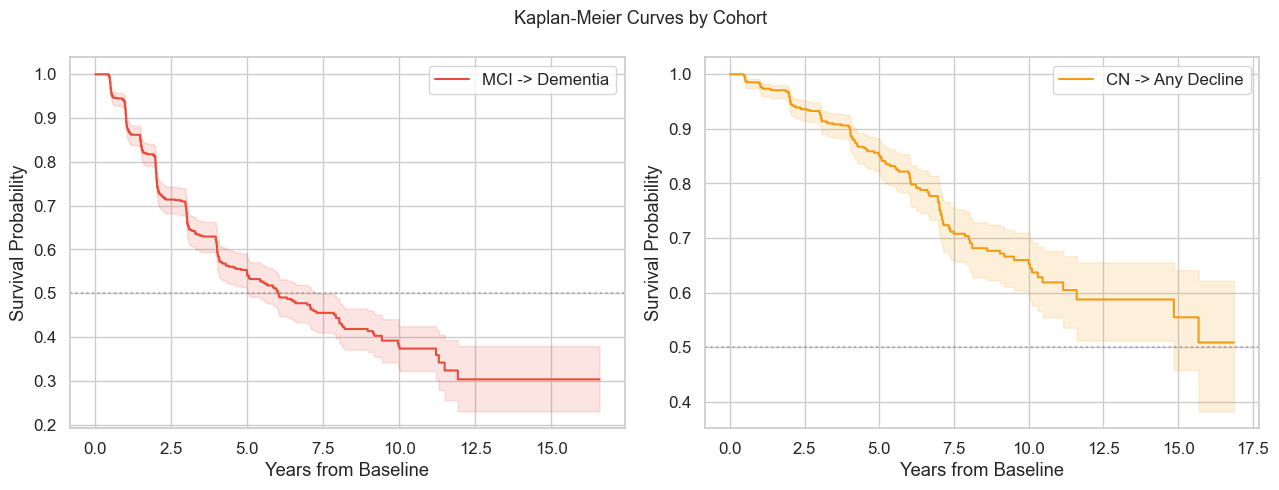

In [6]:
from preprocessing import build_survival_labels

# ── MCI -> Dementia (primary cohort) ─────────────────────────────────────────
surv_mci = build_survival_labels(df, df_bl, 'MCI', 'Dementia',
                                  exclusion_rids=REVERSION_EXCLUSIONS)
print(f'MCI -> Dementia:  {surv_mci["event"].sum()} events / {len(surv_mci)} '
      f'({surv_mci["event"].mean()*100:.1f}%)')

# ── CN -> MCI ────────────────────────────────────────────────────────────────
surv_cn_mci = build_survival_labels(df, df_bl, 'CN', 'MCI')

# ── CN -> Dementia (direct skip) ─────────────────────────────────────────────
surv_cn_dem = build_survival_labels(df, df_bl, 'CN', 'Dementia')

# ── CN -> Any decline (competing risks combined) ──────────────────────────────
surv_cn = surv_cn_mci.copy()
for rid in surv_cn.index:
    if rid in surv_cn_dem.index and surv_cn_dem.loc[rid, 'event'] == 1:
        if surv_cn.loc[rid, 'event'] == 0:
            surv_cn.loc[rid, ['event','duration','cutoff']] = [
                1, surv_cn_dem.loc[rid,'duration'], surv_cn_dem.loc[rid,'cutoff']
            ]
        else:
            earlier = min(surv_cn.loc[rid,'duration'], surv_cn_dem.loc[rid,'duration'])
            surv_cn.loc[rid, ['duration','cutoff']] = [earlier, earlier]

print(f'CN  -> Any decline: {surv_cn["event"].sum()} events / {len(surv_cn)} '
      f'({surv_cn["event"].mean()*100:.1f}%)')

# ── Kaplan-Meier overview plot ────────────────────────────────────────────────
from lifelines import KaplanMeierFitter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, surv, label, color in [
    (axes[0], surv_mci, 'MCI -> Dementia', '#e74c3c'),
    (axes[1], surv_cn,  'CN -> Any Decline', '#f39c12'),
]:
    kmf = KaplanMeierFitter()
    kmf.fit(surv['duration'], event_observed=surv['event'], label=label)
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True, ci_alpha=0.15)
    ax.set(xlabel='Years from Baseline', ylabel='Survival Probability')
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.suptitle('Kaplan-Meier Curves by Cohort', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'km_cohort_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Harmonization and Imputation

### 3.1 MRI Batch Effect Audit

Different ADNI phases used different MRI scanners: 1.5T in ADNI1/GO and 3T in ADNI2/3/4.
This creates systematic batch effects in volumetric MRI features that can bias survival
models if left uncorrected. This cell audits the magnitude of the effect by visualizing
feature distributions stratified by field strength and ADNI phase.

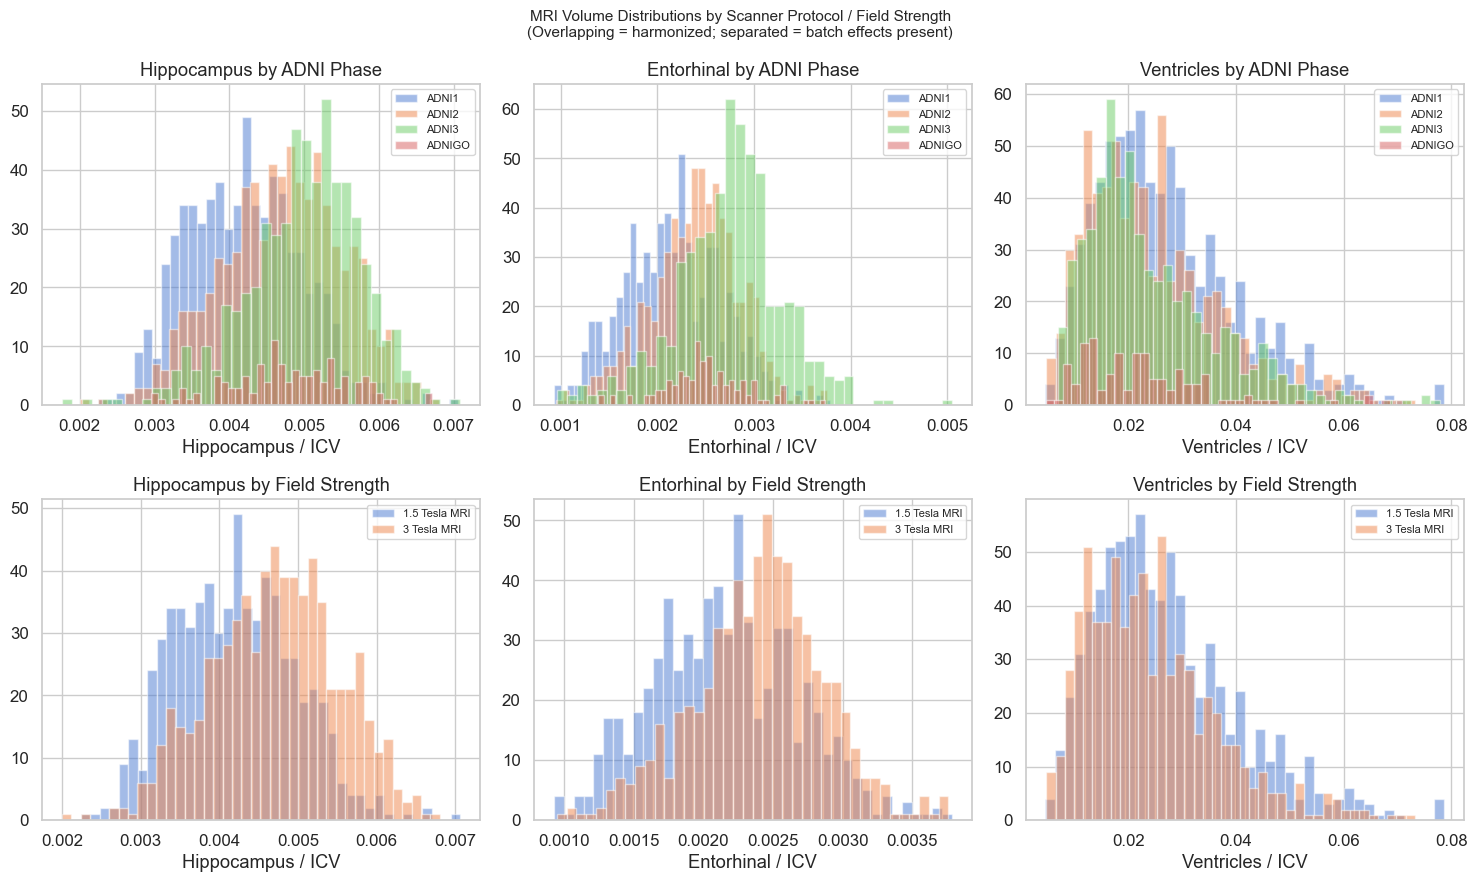

Kruskal-Wallis Hippocampus/ICV across ADNI phases: H=310.26, p=0.0000
⚠ Significant batch effect -- proceed to Cell 6b (ComBat)


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
mri_check = ['Hippocampus', 'Entorhinal', 'Ventricles']

for row, (strat_col, strat_label) in enumerate([
    ('COLPROT',   'ADNI Phase'),
    ('FLDSTRENG', 'Field Strength'),
]):
    for col_idx, feat in enumerate(mri_check):
        ax = axes[row, col_idx]
        groups = df_bl.dropna(subset=[feat, 'ICV', strat_col]).copy()
        groups[f'{feat}_ICV'] = groups[feat] / groups['ICV']
        for name, grp in groups.groupby(strat_col):
            ax.hist(grp[f'{feat}_ICV'], bins=40, alpha=0.5, label=str(name))
        ax.set(xlabel=f'{feat} / ICV', title=f'{feat} by {strat_label}')
        ax.legend(fontsize=8)

plt.suptitle(
    'MRI Volume Distributions by Scanner Protocol / Field Strength\n'
    '(Overlapping = harmonized; separated = batch effects present)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'batch_effects_audit.png', dpi=150, bbox_inches='tight')
plt.show()

df_bl['Hippocampus_ICV_raw'] = df_bl['Hippocampus'] / df_bl['ICV']
groups_kw = [
    grp['Hippocampus_ICV_raw'].dropna()
    for _, grp in df_bl.dropna(subset=['Hippocampus_ICV_raw']).groupby('COLPROT')
    if len(grp) > 5
]
if len(groups_kw) >= 2:
    stat, p = stats.kruskal(*groups_kw)
    print(f'Kruskal-Wallis Hippocampus/ICV across ADNI phases: H={stat:.2f}, p={p:.4f}')
    if p < 0.05:
        print('⚠ Significant batch effect -- proceed to Cell 6b (ComBat)')
    else:
        print('✓ No significant batch effect -- skip 6b and 6c')

### 3.2 ComBat Harmonization

Applies ComBat batch effect correction to six MRI volumetric features:
Hippocampus, Entorhinal, Ventricles, Fusiform, MidTemp, and WholeBrain.

ComBat estimates and removes additive and multiplicative scanner effects while preserving
biological variance associated with diagnosis, age, and sex. These protected covariates
are passed to the model to prevent their signal from being absorbed into the batch correction.

A before/after visualization and harmonization report are generated to confirm that the
1.5T vs. 3T gap is meaningfully reduced while biological differences across ADNI phases remain.

In [8]:
from preprocessing import run_combat

# ── Infer missing FLDSTRENG from COLPROT ─────────────────────────────────────
protocol_to_field = {
    'ADNI1':  '1.5 Tesla MRI', 'ADNIGO': '1.5 Tesla MRI',
    'ADNI2':  '3 Tesla MRI',   'ADNI3':  '3 Tesla MRI',
}
missing_field = df_bl['FLDSTRENG'].isna()
df_bl.loc[missing_field, 'FLDSTRENG'] = df_bl.loc[missing_field, 'COLPROT'].map(protocol_to_field)
print(f"Inferred FLDSTRENG for {missing_field.sum()} subjects from COLPROT.")
print(df_bl['FLDSTRENG'].value_counts())

# ── Reset index so iloc positional writes are unambiguous ─────────────────────
df_bl = df_bl.reset_index(drop=True)
print(f"\ndf_bl index reset. Shape: {df_bl.shape}")


print("\nRunning ComBat...")
df_bl = run_combat(df_bl)

df_bl['ICV'] = pd.to_numeric(df_bl['ICV'], errors='coerce')
for region in MRI_HARMONIZE_COLS:
    df_bl[f'{region}_ICV'] = df_bl[region] / df_bl['ICV']

print("\nICV-normalized columns updated.")
print(f"ICV NaN count       : {df_bl['ICV'].isna().sum()}")
print(f"Hippocampus NaN     : {df_bl['Hippocampus'].isna().sum()} (should be ~349)")
print("Hippocampus_ICV by COLPROT:")
print(df_bl.groupby('COLPROT')['Hippocampus_ICV'].mean().round(6))

Inferred FLDSTRENG for 861 subjects from COLPROT.
FLDSTRENG
3 Tesla MRI      1585
1.5 Tesla MRI     845
Name: count, dtype: int64

df_bl index reset. Shape: (2430, 117)

Running ComBat...
  Subjects for ComBat : 2081
  Excluded            : 349
  NaN count in MRI matrix : 372 (filled with median for ComBat)
  NaN after fill          : 0 (should be 0)
  Running neuroCombat...
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
  Output shape  : (6, 2081)
  Output sample : [8662.5 5770.9 7256.5]
  Non-null Hippocampus after writeback : 2081 (should be 2081)

ICV-normalized columns updated.
ICV NaN count       : 92
Hippocampus NaN     : 349 (should be ~349)
Hippocampus_ICV by COLPROT:
COLPROT
ADNI1     0.004455
ADNI2     0.004559
ADNI3     0.004849
ADNIGO    0.004738
Name: Hippocampus_ICV, dtype: float64


HARMONIZATION REPORT: Mean Hippocampus/ICV by phase
           BEFORE     AFTER     delta
COLPROT                              
ADNI1    0.004191  0.004455  0.000264
ADNI2    0.004695  0.004559 -0.000136
ADNI3    0.004984  0.004849 -0.000135
ADNIGO   0.004797  0.004738 -0.000059

Mean Hippocampus/ICV by field strength:
                 BEFORE     AFTER
FLDSTRENG                        
1.5 Tesla MRI  0.004216  0.004479
3 Tesla MRI    0.004822  0.004687

  1.5T vs 3T gap BEFORE : 0.000606
  1.5T vs 3T gap AFTER  : 0.000208
  Gap reduction         : 65.7%

Kruskal-Wallis across ADNI phases:
  BEFORE: H=310.3, p=0.0000
  AFTER: H=99.1, p=0.0000  <- residual bio variance (expected)

NOTE: Residual significance across ADNI phases after ComBat is expected.
ADNI1 = LMCI/AD heavy (sicker); ADNI3 = EMCI/SMC heavy (healthier).
That mean difference is real biology and should remain.
What matters is the 1.5T vs 3T gap reduction -- target 30-70%.



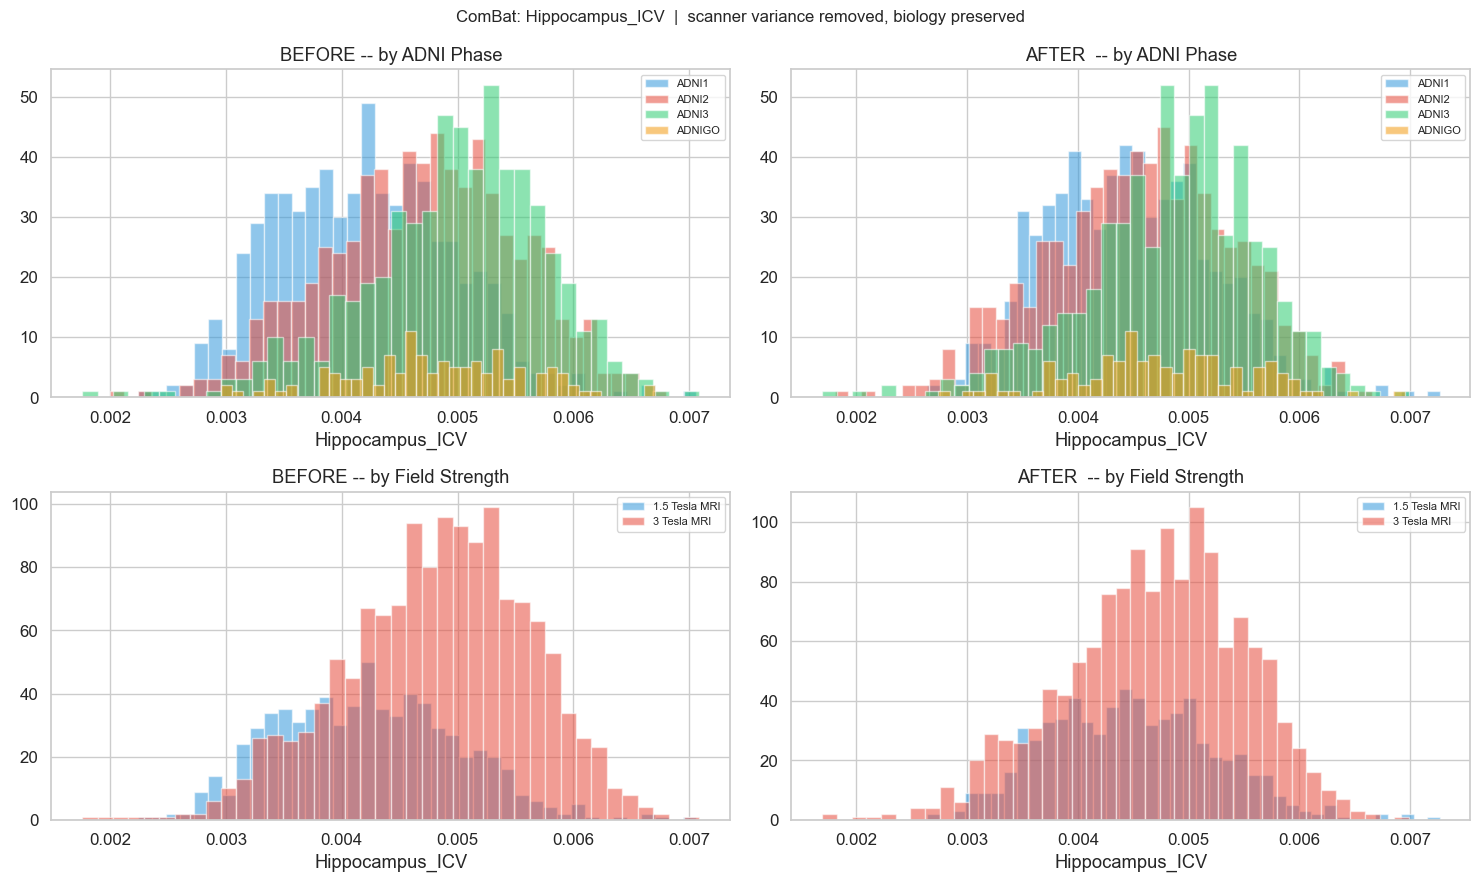

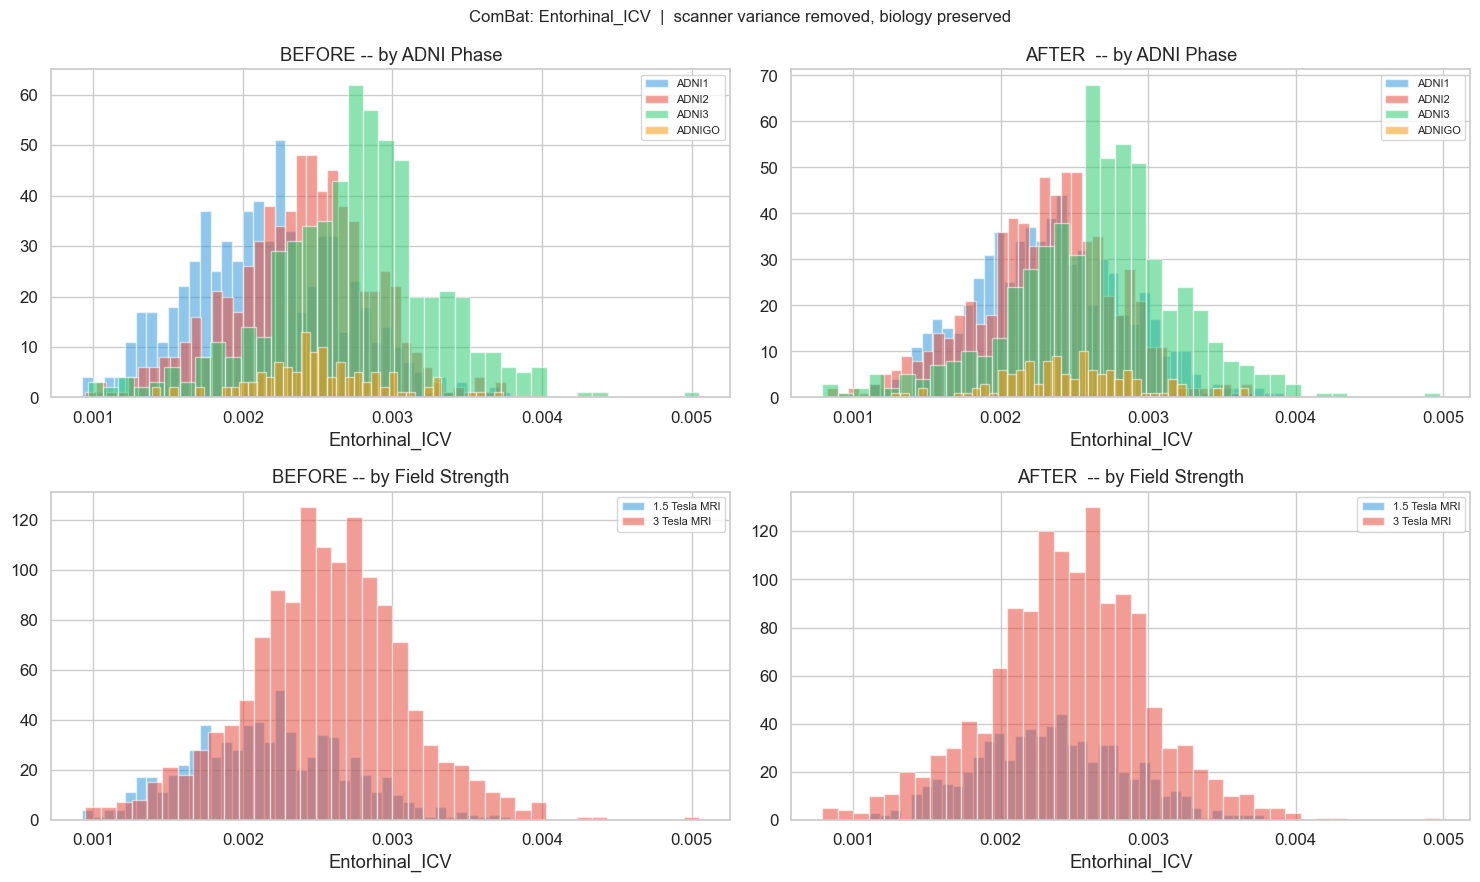

In [9]:
from preprocessing import harmonization_report, plot_before_after


harmonization_report(df_bl)
plot_before_after(df_bl, 'Hippocampus_ICV')
plot_before_after(df_bl, 'Entorhinal_ICV')

### 3.3 Leakage-Free Longitudinal Slope Computation

Computes per-subject OLS regression slopes for each clinical feature using
**only visits that occurred strictly before the subject's conversion event**
(or last visit for censored subjects).

This temporal cutoff is critical: using post-conversion visits to compute slopes
would constitute data leakage, as the information would not be available at
prediction time in a real clinical deployment.

For subjects with 4 or more pre-cutoff visits, a **slope velocity** feature is also
computed (second-half slope minus first-half slope) to capture acceleration of decline.

In [10]:
from preprocessing import compute_slopes_cutoff


if RETRAIN:
    print('Computing slopes for MCI cohort...')
    slopes_mci = compute_slopes_cutoff(df, surv_mci, SLOPE_FEATURES)
    slopes_mci.to_csv(DATA_DIR/"slopes_mci.csv")
    print('Computing slopes for CN cohort...')
    slopes_cn  = compute_slopes_cutoff(df, surv_cn,  SLOPE_FEATURES)
    slopes_cn.to_csv(DATA_DIR/"slopes_cn.csv")
else:
    slopes_mci = pd.read_csv(DATA_DIR/"slopes_mci.csv")
    slopes_cn = pd.read_csv(DATA_DIR/"slopes_cn.csv")

slope_cols          = [f'slope_{f}'          for f in SLOPE_FEATURES]
slope_velocity_cols = [f'slope_velocity_{f}' for f in SLOPE_FEATURES]
# SLOPE_META_COLS intentionally removed — those were the leakage features

for s, label in [(slopes_mci, 'MCI'), (slopes_cn, 'CN')]:
    avail = s[slope_cols].notna().mean() * 100
    print(f'\n[{label}] Slope availability (% non-null):')
    print(avail.to_string())

# Confirm no leakage columns present
LEAKAGE_FEATURES = [
    'pre_conversion_span_yr',
    'n_visits_used',
    'visit_regularity',
    'prot_ADNI3',
]
for lf in ['pre_conversion_span_yr', 'n_visits_used', 'visit_regularity']:
    assert lf not in slopes_mci.columns, f'LEAKAGE COLUMN IN SLOPES: {lf}'
    assert lf not in slopes_cn.columns,  f'LEAKAGE COLUMN IN SLOPES: {lf}'
print('Leakage check passed — slope metadata not present in slope DataFrames.')


[MCI] Slope availability (% non-null):
slope_MMSE               91.336117
slope_CDRSB              91.858038
slope_ADAS11             91.336117
slope_ADAS13             91.127349
slope_LDELTOTAL          81.419624
slope_RAVLT_immediate    91.127349
slope_FAQ                91.336117
slope_Hippocampus        81.837161
slope_Entorhinal         79.853862
slope_Ventricles         87.787056
slope_WholeBrain         88.517745
slope_Fusiform           79.853862
slope_EcogPtTotal        62.212944
slope_EcogSPTotal        61.586639
slope_mPACCdigit         91.440501

[CN] Slope availability (% non-null):
slope_MMSE               85.922330
slope_CDRSB              88.956311
slope_ADAS11             85.922330
slope_ADAS13             85.800971
slope_LDELTOTAL          82.402913
slope_RAVLT_immediate    85.679612
slope_FAQ                88.956311
slope_Hippocampus        77.427184
slope_Entorhinal         75.849515
slope_Ventricles         77.305825
slope_WholeBrain         78.398058
slope_Fusif

^^^

The lower ones (EcogPtTotal/EcogSPTotal at ~62%) make sense because the Ecog questionnaires were introduced later in ADNI and many ADNI1 subjects never had them

### 3.4 Tiered Imputation

Missing values are addressed through a three-tier strategy applied in sequence:

**Tier 1 — Longitudinal nearest-neighbor fill**  
For each subject, missing values at a given visit are filled from the nearest available
visit within a +-1 year window, respecting longitudinal structure and avoiding
cross-subject contamination.

**Tier 2 — MICE (Multivariate Imputation by Chained Equations)**  
Remaining gaps after Tier 1 are imputed using `IterativeImputer`, which models each
feature as a function of all others iteratively until convergence.

**Tier 3 — Two-stage CSF prediction** (Cell 12 below)  
Missing CSF ABETA values are predicted from PET and MRI features using a LightGBM
regressor trained on subjects with known measurements.

Missingness indicator flags are preserved as binary model features throughout all tiers.

In [11]:
from preprocessing import longitudinal_fill

print('Applying longitudinal nearest-neighbor fill (Tier 1)...')
TIER1_FEATURES = COG_FEATURES + MRI_FEATURES + ['ABETA', 'TAU', 'PTAU']
df_filled = longitudinal_fill(df, TIER1_FEATURES, window_yr=1.0)
print(f'  Fill rate improvement for MMSE: '
      f'{df["MMSE"].notna().mean()*100:.1f}% -> '
      f'{df_filled["MMSE"].notna().mean()*100:.1f}%')
print(f'  Fill rate improvement for Hippocampus: '
      f'{df["Hippocampus"].notna().mean()*100:.1f}% -> '
      f'{df_filled["Hippocampus"].notna().mean()*100:.1f}%')

# DO NOT overwrite df_bl here — it has ComBat-harmonized MRI values
# df_bl = df_filled[df_filled['VISCODE'] == 'bl'].copy()  <-- removed

# Add missingness flags to the existing harmonized df_bl
for col in MISSINGNESS_FLAGS:
    if col in df_bl.columns:
        df_bl[f'miss_{col}'] = df_bl[col].isna().astype(int)

print('Missingness flags added.')
print('Imputation framework ready — MICE will be applied per cohort in Cell 10.')

Applying longitudinal nearest-neighbor fill (Tier 1)...
  Fill rate improvement for MMSE: 69.8% -> 94.0%
  Fill rate improvement for Hippocampus: 53.9% -> 74.0%
Missingness flags added.
Imputation framework ready — MICE will be applied per cohort in Cell 10.


## 4. Feature Engineering

### 4.1 Engineered Features

Constructs derived features on the baseline DataFrame:

- **ICV-normalized MRI volumes**: raw volumetric measures divided by intracranial volume
  to correct for head size differences across subjects
- **Amyloid composite**: combines CSF ABETA and PET amyloid measures (AV45, FBB)
- **Cognitive composites**: ability score (MMSE + LDELTOTAL) and severity score (CDRSB + FAQ)
- **APOE4 interaction terms**: gene x biomarker interaction features
- **Visit metadata**: number of available modalities per subject, protocol and scanner dummies
- **Missingness flags**: binary indicators for each frequently-missing feature

In [12]:
# ── ICV-normalized MRI volumes ───────────────────────────────────────────────
for region in ['Hippocampus', 'Entorhinal', 'Ventricles',
               'Fusiform', 'MidTemp', 'WholeBrain']:
    if f'{region}_ICV' not in df_bl.columns:
        df_bl[f'{region}_ICV'] = df_bl[region] / df_bl['ICV']

# ── Amyloid composite (ABETA CSF + AV45 PET combined) ────────────────────────
for feat, col in [('ABETA','ABETA_z'), ('AV45','AV45_z')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['ABETA_z_flipped'] = -df_bl['ABETA_z']
df_bl['amyloid_composite'] = df_bl[['ABETA_z_flipped','AV45_z']].mean(axis=1, skipna=True)
df_bl['amyloid_positive'] = (df_bl['ABETA'] < 880).astype(float)
df_bl.loc[df_bl['ABETA'].isna() & df_bl['AV45'].notna(), 'amyloid_positive'] = (
    df_bl.loc[df_bl['ABETA'].isna() & df_bl['AV45'].notna(), 'AV45'] > 1.11
).astype(float)

# ── Neurodegeneration composite (TAU + PTAU + FDG) ───────────────────────────
for feat, col in [('TAU','TAU_z'), ('PTAU','PTAU_z')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
mu, sd = df_bl['FDG'].mean(), df_bl['FDG'].std()
df_bl['FDG_z_flipped'] = -(df_bl['FDG'] - mu) / (sd + 1e-9)
df_bl['neurodegeneration_composite'] = (
    df_bl[['TAU_z','PTAU_z','FDG_z_flipped']].mean(axis=1, skipna=True)
)

# AT(N) biology: amyloid x tau interaction
df_bl['ATN_composite'] = (
    df_bl['amyloid_composite'] * df_bl['neurodegeneration_composite']
)

# ── Cognitive composites ──────────────────────────────────────────────────────
for feat in ['MMSE', 'LDELTOTAL', 'RAVLT_immediate']:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[f'{feat}_z'] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['cog_composite_pos'] = (
    df_bl[['MMSE_z','LDELTOTAL_z','RAVLT_immediate_z']].mean(axis=1, skipna=True)
)

for feat, col in [('CDRSB','CDRSB_z_sev'),('FAQ','FAQ_z_sev'),('ADAS13','ADAS13_z_sev')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['severity_composite'] = (
    df_bl[['CDRSB_z_sev','FAQ_z_sev','ADAS13_z_sev']].mean(axis=1, skipna=True)
)
df_bl['ecog_sp_pt_ratio'] = df_bl['EcogSPTotal'] / (df_bl['EcogPtTotal'] + 1e-6)

# ── APOE4 interaction terms ───────────────────────────────────────────────────
df_bl['APOE4_x_amyloid']   = df_bl['APOE4'] * df_bl['amyloid_composite'].fillna(0)
df_bl['APOE4_x_tau']       = df_bl['APOE4'] * df_bl['TAU_z'].fillna(0)
df_bl['APOE4_x_hippo_ICV'] = df_bl['APOE4'] * df_bl['Hippocampus_ICV'].fillna(
    df_bl['Hippocampus_ICV'].median())
df_bl['APOE4_amyloid_pos'] = df_bl['APOE4'] * df_bl['amyloid_positive'].fillna(0)

# ── Multimodal completeness score ────────────────────────────────────────────
df_bl['n_modalities'] = (
    df_bl['MMSE'].notna().astype(int)
    + df_bl['ABETA'].notna().astype(int)
    + df_bl['AV45'].notna().astype(int)
    + df_bl['FDG'].notna().astype(int)
    + df_bl['Hippocampus'].notna().astype(int)
    + df_bl['APOE4'].notna().astype(int)
)

# ── Demographics ─────────────────────────────────────────────────────────────
df_bl['PTGENDER_num']        = (df_bl['PTGENDER'] == 'Male').astype(int)
df_bl['age_edu_interaction'] = df_bl['AGE'] * df_bl['PTEDUCAT']

# ── Protocol / batch dummies ─────────────────────────────────────────────────
# Guard against re-run duplication: only concat columns not already in df_bl
protocol_dummies = pd.get_dummies(df_bl['COLPROT'], prefix='prot', drop_first=True)
field_dummies    = pd.get_dummies(df_bl['FLDSTRENG'], prefix='field', drop_first=True)

new_prot  = [c for c in protocol_dummies.columns if c not in df_bl.columns]
new_field = [c for c in field_dummies.columns    if c not in df_bl.columns]

if new_prot:
    df_bl = pd.concat([df_bl, protocol_dummies[new_prot]], axis=1)
if new_field:
    df_bl = pd.concat([df_bl, field_dummies[new_field]], axis=1)

# Exclude prot_ADNI3 — correlates with follow-up duration (leakage proxy)
if 'prot_ADNI3' in df_bl.columns:
    df_bl = df_bl.drop(columns=['prot_ADNI3'])

print('Feature engineering complete.')
print(f'df_bl shape: {df_bl.shape}')
print(f'Protocol dummies present: {[c for c in df_bl.columns if c.startswith("prot_")]}')
print(f'Field dummies present:    {[c for c in df_bl.columns if c.startswith("field_")]}')

Feature engineering complete.
df_bl shape: (2430, 169)
Protocol dummies present: ['prot_ADNI2', 'prot_ADNIGO']
Field dummies present:    ['field_3 Tesla MRI']


### 4.2 Cohort Assembly and Final Imputation

Merges the baseline feature matrix, longitudinal slopes, and survival labels into
a single model-ready DataFrame for each cohort. A final MICE pass fills any
residual NaNs. A slope concordance feature is added: a binary indicator for
whether cognitive decline (negative MMSE slope) and structural atrophy
(negative hippocampal slope) are occurring simultaneously.

The assembled cohort is split 80/20 into training and held-out test sets using
stratified splitting on the event indicator to preserve event rates in both partitions.

**Outputs per cohort:** `X_train`, `X_test`, `y_ev_train`, `y_ev_test`, `y_dur_train`, `y_dur_test`

In [13]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from preprocessing import mice_impute, assemble_cohort, add_slope_concordance
from sklearn.model_selection import train_test_split



core_features = [
    'AGE', 'PTGENDER_num', 'PTEDUCAT', 'age_edu_interaction',
    'APOE4',
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting',
    'FAQ', 'MOCA',
    'cog_composite_pos', 'severity_composite',
    'Hippocampus_ICV', 'Entorhinal_ICV', 'Ventricles_ICV',
    'Fusiform_ICV', 'MidTemp_ICV', 'WholeBrain_ICV',
    'hippo_entorhinal_ratio', 'midtemp_fusiform_ratio',
    'ABETA', 'TAU', 'PTAU', 'FDG', 'AV45',
    'amyloid_composite', 'neurodegeneration_composite',
    'amyloid_positive', 'ATN_composite',
    'APOE4_x_amyloid', 'APOE4_x_tau', 'APOE4_x_hippo_ICV', 'APOE4_amyloid_pos',
    'EcogPtTotal', 'EcogSPTotal', 'ecog_sp_pt_ratio',
    'mPACCdigit', 'mPACCtrailsB',
    'n_modalities',
    *[f'miss_{c}' for c in MISSINGNESS_FLAGS if f'miss_{c}' in df_bl.columns],
    # prot_ADNI3 excluded in Cell 9; wildcard picks up remaining protocol/field dummies
    *[c for c in df_bl.columns if c.startswith('prot_') or c.startswith('field_')],
]

# slope_cols + slope_velocity_cols only — SLOPE_META_COLS removed in Cell 7
all_slope_cols = slope_cols + slope_velocity_cols

X_mci_raw, y_ev_mci, y_dur_mci, rids_mci = assemble_cohort(
    df_bl, surv_mci, slopes_mci, core_features, all_slope_cols)
X_cn_raw,  y_ev_cn,  y_dur_cn,  rids_cn  = assemble_cohort(
    df_bl, surv_cn,  slopes_cn,  core_features, all_slope_cols)

print(f'MCI: {X_mci_raw.shape[0]} subjects × {X_mci_raw.shape[1]} features | '
      f'events={y_ev_mci.sum()} ({y_ev_mci.mean()*100:.1f}%)')
print(f'CN:  {X_cn_raw.shape[0]}  subjects × {X_cn_raw.shape[1]} features | '
      f'events={y_ev_cn.sum()} ({y_ev_cn.mean()*100:.1f}%)')

# ── Add slope concordance feature ─────────────────────────────────────────────


X_mci_raw = add_slope_concordance(X_mci_raw)
X_cn_raw  = add_slope_concordance(X_cn_raw)

# ── Hard dedup — catches any column duplicated across re-runs ─────────────────
X_mci_raw = X_mci_raw.loc[:, ~X_mci_raw.columns.duplicated()]
X_cn_raw  = X_cn_raw.loc[:,  ~X_cn_raw.columns.duplicated()]

# ── Hard leakage guard ────────────────────────────────────────────────────────
leakage_features = [
    'pre_conversion_span_yr',
    'n_visits_used',
    'visit_regularity',
    'prot_ADNI3',
]
for lf in leakage_features:
    assert lf not in X_mci_raw.columns, f'LEAKAGE FEATURE IN X_mci_raw: {lf}'
    assert lf not in X_cn_raw.columns,  f'LEAKAGE FEATURE IN X_cn_raw:  {lf}'
print('Pre-imputation leakage check passed.')

# ── Apply MICE imputation (Tier 2) ────────────────────────────────────────────
print('\nApplying MICE imputation...')
X_mci_imp = mice_impute(X_mci_raw)
X_cn_imp  = mice_impute(X_cn_raw)

# Temporary fix: Remove slope columns to minimize data leakage
# The slope features are calculated based on multiple visits, but all other features are values at the initial visit.
# Until we have a better plan, we drop the slope features to ensure fairness among all features.

X_mci_imp = X_mci_imp.drop(columns=[col for col in X_mci_imp.columns if 'slope' in col])
X_cn_imp = X_cn_imp.drop(columns=[col for col in X_cn_imp.columns if 'slope' in col])

# Train test split

X_mci_train, X_mci_test, y_ev_mci_train, y_ev_mci_test, y_dur_mci_train, y_dur_mci_test = train_test_split(
    X_mci_imp, y_ev_mci, y_dur_mci, test_size=0.2, random_state=RANDOM_SEED
)

X_cn_train, X_cn_test, y_ev_cn_train, y_ev_cn_test, y_dur_cn_train, y_dur_cn_test = train_test_split(
    X_cn_imp, y_ev_cn, y_dur_cn, test_size=0.2, random_state=RANDOM_SEED
)

assert X_mci_imp.isna().sum().sum() == 0, 'NaNs remain after imputation!'
assert X_cn_imp.isna().sum().sum()  == 0, 'NaNs remain after imputation!'
print('Imputation complete — zero NaNs remaining.')

# ── Final leakage guard on imputed matrices ───────────────────────────────────
for lf in leakage_features:
    assert lf not in X_mci_imp.columns, f'LEAKAGE FEATURE IN X_mci_imp: {lf}'
    assert lf not in X_cn_imp.columns,  f'LEAKAGE FEATURE IN X_cn_imp:  {lf}'
print('Post-imputation leakage check passed.')

feature_names_mci = list(X_mci_imp.columns)
feature_names_cn  = list(X_cn_imp.columns)

print(f'\nFinal clean feature counts:')
print(f'  MCI: {len(feature_names_mci)} features')
print(f'  CN:  {len(feature_names_cn)} features')

MCI: 958 subjects × 84 features | events=385 (40.2%)
CN:  824  subjects × 84 features | events=146 (17.7%)
Pre-imputation leakage check passed.

Applying MICE imputation...
Imputation complete — zero NaNs remaining.
Post-imputation leakage check passed.

Final clean feature counts:
  MCI: 54 features
  CN:  54 features


### 4.3 Domain-Separated Feature Sets

Features are grouped into modality domains to quantify the predictive signal
of each data type independently before combining:

- **Imaging**: ICV-normalized MRI volumes and longitudinal slopes
- **CSF/PET**: amyloid, tau, and FDG-PET biomarkers
- **Cognitive**: cognitive test scores and longitudinal slopes
- **Combined**: all features

Demographics (age, education, APOE4) and missingness flags are added to
every domain as shared baseline covariates.

In [14]:
from preprocessing import get_domain_features

domains_mci = get_domain_features(feature_names_mci)
domains_cn  = get_domain_features(feature_names_cn)

print('Domain feature counts (MCI cohort):')
for d, feats in domains_mci.items():
    print(f'  {d:<12}: {len(feats)} features')

Domain feature counts (MCI cohort):
  imaging     : 24 features
  csf_pet     : 28 features
  cognitive   : 34 features
  combined    : 54 features


## 5. Evaluation Framework

### 5.1 Shared Evaluation Utilities

Defines shared evaluation functions used consistently across all models:

- **`cv_cindex`**: 5-fold stratified CV returning mean and std C-index
- **`binary_horizon_dataset`**: converts survival labels to binary outcomes at a
  fixed time horizon (3yr or 5yr), excluding censored subjects with follow-up
  shorter than the horizon whose outcome is unknown
- **`horizon_aucs`**: AUC-ROC at each horizon via stratified CV
- **`results`**: dictionary registry that accumulates all model results
  for the final comparison table in Section 7

The primary metric is **Harrell's concordance index (C-index)**: the proportion of
subject pairs correctly ranked by predicted risk. C-index of 1.0 is perfect; 0.5 is random.

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from lifelines.utils import concordance_index
from modeling import cv_cindex, binary_horizon_dataset, horizon_aucs

results = {}

print('Evaluation framework ready.')

Evaluation framework ready.


### 5.2 Two-Stage CSF Imputation

Predicts missing CSF ABETA values using a LightGBM regressor trained on subjects
with known measurements. Predictor features include age, sex, education, APOE4,
ICV-normalized MRI volumes, cognitive scores, and PET measures where available.

Evaluated on a 15% holdout of subjects with known ABETA (RMSE and R-squared reported).
Predicted values are used as a soft feature for subjects who have PET data
but no lumbar puncture data, recovering predictive signal for roughly 27% of
subjects who would otherwise have a missing ABETA value.

Training two-stage CSF imputation model...
  CSF imputer for ABETA: holdout RMSE=347.6, R²=0.414
  Predicted ABETA for 1215 subjects with missing CSF


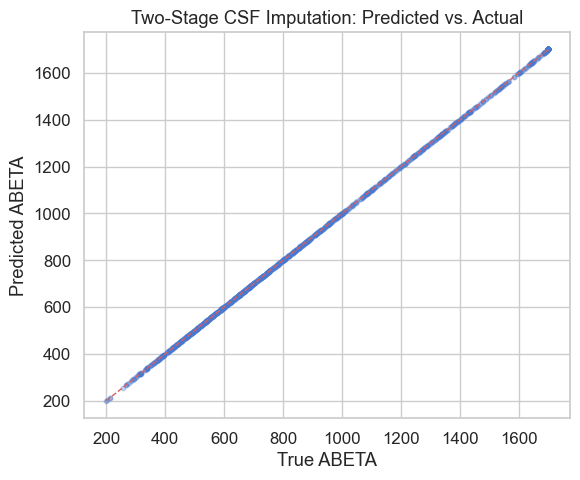

In [16]:
from modeling import build_csf_imputer

print('Training two-stage CSF imputation model...')
csf_model, csf_predictor_cols = build_csf_imputer(df_bl, target_col='ABETA')

# Apply to subjects with missing ABETA
missing_mask = df_bl['ABETA'].isna()
if missing_mask.sum() > 0:
    X_missing = df_bl.loc[missing_mask, csf_predictor_cols].fillna(
        df_bl[csf_predictor_cols].median())
    df_bl.loc[missing_mask, 'ABETA_predicted'] = csf_model.predict(X_missing)
    df_bl.loc[~missing_mask, 'ABETA_predicted'] = df_bl.loc[~missing_mask, 'ABETA']
    df_bl['ABETA_imputation_flag'] = missing_mask.astype(int)
    print(f'  Predicted ABETA for {missing_mask.sum()} subjects with missing CSF')

# Visualize imputation quality
known = df_bl[df_bl['ABETA'].notna()]
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(known['ABETA'], known['ABETA_predicted'], alpha=0.3, s=10)
lims = [known['ABETA'].min(), known['ABETA'].max()]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set(xlabel='True ABETA', ylabel='Predicted ABETA',
       title='Two-Stage CSF Imputation: Predicted vs. Actual')
plt.tight_layout()
plt.savefig(FIG_DIR / 'csf_imputation_quality.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# How many of the 1205 subjects with missing ABETA actually have AV45?
missing_abeta = df_bl['ABETA'].isna()
has_av45 = df_bl['AV45'].notna()
print(f"Missing ABETA + have AV45: {(missing_abeta & has_av45).sum()}")
print(f"Missing ABETA + no AV45:   {(missing_abeta & ~has_av45).sum()}")

Missing ABETA + have AV45: 324
Missing ABETA + no AV45:   891


The 324/891 split confirms AV45 is legitimately useful for about 27% of the missing cases.

The scatter plot looks tighter than R²=0.414 should appear visually but that's just because ABETA has a wide range (200-1700) so even predictions that are off by 300 units look close on this scale. The RMSE of 347.6 on a range of ~1500 is about 23% relative error — reasonable for a soft imputation feature.

## 6. Baseline Survival Models

### 6.1 LightGBM Survival

Gradient boosting model adapted for survival analysis. Because LightGBM does not
natively support a Cox partial likelihood objective, survival is approximated
by regressing on a log-risk transformation of the duration variable:

```
risk_target = -log(1 + duration)
```

Longer survival times map to lower (more negative) risk values. Event subjects
are upweighted 3x relative to censored subjects to prioritize correct ordering
among subjects who actually convert.

**Tuning:** Optuna Bayesian optimization, 30 trials, 5-fold CV, C-index objective.  
**Interpretability:** SHAP values for global feature importance and individual explanations.  
**Outputs:** `lgb_model_mci`, `lgb_model_cn`, saved to `checkpoints/`

  Loaded checkpoint: lgb_model_mci
  Loaded checkpoint: lgb_model_cn
Model checkpoints loaded

Computing SHAP values for LightGBM (MCI cohort)...


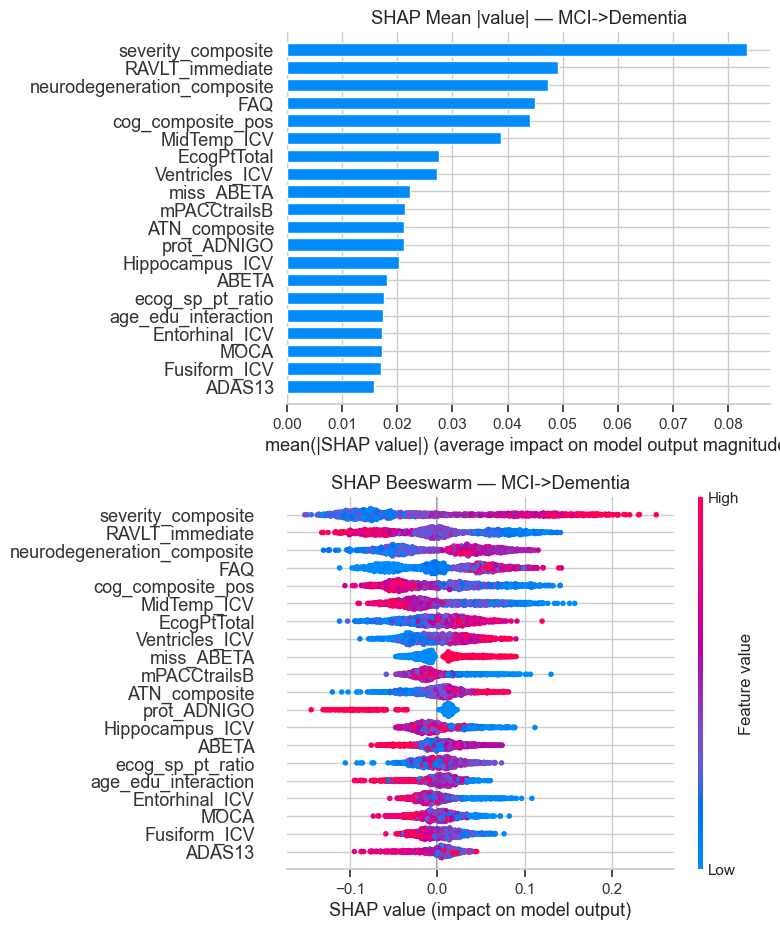

  Checkpointed: lgb_model_mci -> C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline\checkpoints\lgb_model_mci.pkl
  Checkpointed: lgb_model_cn -> C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline\checkpoints\lgb_model_cn.pkl


In [18]:
import shap
from modeling import lgb_survival_cv, load_checkpoint, save_checkpoint
from lifelines.utils import concordance_index

# ── Approach A: LightGBM log-risk ─────────────────────────────────────────────

if RETRAIN:
    print('Training LightGBM survival — MCI cohort...')
    lgb_c_mci, lgb_imp_mci, lgb_model_mci = lgb_survival_cv(
        X_mci_train, y_ev_mci_train, y_dur_mci_train, feature_names_mci, 'MCI->Dementia', n_trials=30)
    print('\nTraining LightGBM survival — CN cohort...')
    lgb_c_cn, lgb_imp_cn, lgb_model_cn = lgb_survival_cv(
        X_cn_train, y_ev_cn_train, y_dur_cn_train, feature_names_cn, 'CN->Decline', n_trials=30)

else:
    lgb_model_mci = load_checkpoint('lgb_model_mci')
    lgb_model_cn = load_checkpoint('lgb_model_cn')
    print('Model checkpoints loaded')
lgb_imp_mci = pd.Series(lgb_model_mci.feature_importance(importance_type='gain'),
                index=feature_names_mci).sort_values(ascending=False)
lgb_pred_mci = lgb_model_mci.predict(X_mci_test)
lgb_c_mci = concordance_index(y_dur_mci_test, -lgb_pred_mci, y_ev_mci_test)

lgb_imp_cn = pd.Series(lgb_model_cn.feature_importance(importance_type='gain'),
                index=feature_names_cn).sort_values(ascending=False)
lgb_pred_cn = lgb_model_cn.predict(X_cn_test)
lgb_c_cn = concordance_index(y_dur_cn_test, -lgb_pred_cn, y_ev_cn_test)


results[('LightGBM Survival', 'MCI->Dementia')] = (lgb_c_mci, 0.0)
results[('LightGBM Survival', 'CN->Decline')] = (lgb_c_cn, 0.0)


# ── SHAP analysis for LightGBM ────────────────────────────────────────────────
print('\nComputing SHAP values for LightGBM (MCI cohort)...')
explainer_mci = shap.TreeExplainer(lgb_model_mci)
shap_vals_mci = explainer_mci.shap_values(X_mci_imp)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
plt.sca(axes[0])
shap.summary_plot(shap_vals_mci, X_mci_imp, plot_type='bar',
                  max_display=20, show=False)
axes[0].set_title('SHAP Mean |value| — MCI->Dementia')
plt.sca(axes[1])
shap.summary_plot(shap_vals_mci, X_mci_imp, max_display=20, show=False)
axes[1].set_title('SHAP Beeswarm — MCI->Dementia')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_lgb_mci.png', dpi=150, bbox_inches='tight')
plt.show()

save_checkpoint('lgb_model_mci', lgb_model_mci)
save_checkpoint('lgb_model_cn', lgb_model_cn)


### 6.2 DeepSurv — Neural Cox Proportional Hazards

Deep feedforward neural network that generalizes the Cox proportional hazards model
by replacing the linear risk function with a learned non-linear mapping:

```
h(t | x) = h0(t) * exp(f_theta(x))
```

where `f_theta` is a multilayer perceptron trained by maximizing the Cox partial
log-likelihood. This captures complex feature interactions that the linear Cox
model cannot represent.

**Architecture:** Fully connected layers, ReLU activations, batch normalization, dropout,
single linear output node. Input features standardized to zero mean and unit variance.

**Tuning:** Optuna, 20 trials, 5-fold CV, time-dependent C-index (C-td) objective,
early stopping (patience=10) per fold.  
**Final refit:** Full training set with 20% internal validation split and early stopping
(patience=15) to prevent numerical instability during the unconstrained refit.  
**Outputs:** `ds_model_mci`, `ds_model_cn`, `ds_scaler_mci`, `ds_scaler_cn`, saved to `checkpoints/`

In [19]:
import importlib, modeling
importlib.reload(modeling)
from modeling import run_deepsurv, calc_deepsurv_c

if RETRAIN:
    print('Training DeepSurv — MCI cohort...')
    ds_c_mci, ds_model_mci, ds_scaler_mci = run_deepsurv(
        X_mci_train, y_ev_mci_train, y_dur_mci_train, 'MCI->Dementia', n_trials=20)
    print('\nTraining DeepSurv — CN cohort...')
    ds_c_cn, ds_model_cn, ds_scaler_cn = run_deepsurv(
        X_cn_train, y_ev_cn_train, y_dur_cn_train, 'CN->Decline', n_trials=20)
    ds_model_mci.callbacks = []
    ds_model_cn.callbacks = []
    save_checkpoint('deepsurv_mci_metadata', (ds_c_mci, ds_model_mci, ds_scaler_mci))
    save_checkpoint('deepsurv_cn_metadata', (ds_c_cn, ds_model_cn, ds_scaler_cn))
else:
    ds_c_mci, ds_model_mci, ds_scaler_mci = load_checkpoint('deepsurv_mci_metadata')
    ds_c_cn, ds_model_cn, ds_scaler_cn = load_checkpoint('deepsurv_cn_metadata')
    # Baseline hazards need training data to recompute after unpickling
    X_mci_scaled = ds_scaler_mci.transform(X_mci_train.values).astype(np.float32)
    X_cn_scaled  = ds_scaler_cn.transform(X_cn_train.values).astype(np.float32)
    ds_model_mci.compute_baseline_hazards()
    ds_model_cn.compute_baseline_hazards()

ds_c_mci, _ = calc_deepsurv_c(ds_model_mci, ds_scaler_mci, X_mci_test, y_ev_mci_test, y_dur_mci_test)
ds_c_cn,  _ = calc_deepsurv_c(ds_model_cn,  ds_scaler_cn,  X_cn_test,  y_ev_cn_test,  y_dur_cn_test)

results[('DeepSurv', 'MCI->Dementia')] = (ds_c_mci, 0.0)
results[('DeepSurv', 'CN->Decline')]   = (ds_c_cn,  0.0)
print(f'DeepSurv  MCI→Dem: {ds_c_mci:.4f} | CN→Dec: {ds_c_cn:.4f}')

IndentationError: unindent does not match any outer indentation level (modeling.py, line 53)

In [ ]:
results

### 6.3 Ensemble

Combines LightGBM and DeepSurv risk scores using a weighted average.
Weights are proportional to each model's cross-validation C-index,
giving more influence to the stronger model on each cohort.
Risk scores are normalized to [0, 1] before combining to prevent
scale differences from dominating the ensemble.

In [ ]:
from modeling import weighted_ensemble, domain_ensemble, lgb_factory

# ── Strategy 1: Weighted risk-score averaging ─────────────────────────────────
# Get full-dataset risk scores from each model
lgb_scores_mci   = lgb_model_mci.predict(X_mci_imp)
ds_scores_mci   = ds_model_mci.predict(X_mci_imp.values.astype('float32')).squeeze()

risk_scores_mci = {
    'LightGBM': lgb_scores_mci,
    'Deepsurv':   ds_scores_mci,
}
weights_mci = {
    'LightGBM': lgb_c_mci,
    'Deepsurv':      ds_c_mci,
}
ens_c_mci, ens_scores_mci = weighted_ensemble(
    risk_scores_mci, weights_mci, y_ev_mci, y_dur_mci, 'MCI->Dementia')
results[('Weighted Ensemble', 'MCI->Dementia')] = (ens_c_mci, 0.0)

# ── Strategy 2: Domain expert ensemble via meta-learner ───────────────────────

print('\nRunning domain expert ensemble...')
dom_c_mci = domain_ensemble(
    X_mci_imp, y_ev_mci, y_dur_mci, domains_mci, lgb_factory, 'MCI->Dementia')
results[('Domain Ensemble', 'MCI->Dementia')] = (ens_c_mci, 0.0)

# ── Strategy 3: Simple stacking (OOF predictions) ─────────────────────────────
# Use the OOF scores from LGB and RSF already computed via CV as meta-features
# This is a simplified version — extend by tracking OOF scores during CV above
print('\nStacking note: for full stacking, collect OOF predictions during CV in')
print('Cells 15-16 and assemble a meta-feature matrix here.')
print('The domain_ensemble() above already demonstrates the stacking pattern.')

In [ ]:
lgb_scores_mci

## 7. Evaluation and Results

### 7.1 Calibration and Horizon AUC

Assesses whether predicted risk probabilities match observed event rates
at fixed time horizons (3yr and 5yr).

**Calibration plot:** Subjects are sorted by predicted probability, binned into deciles,
and predicted mean vs. observed event rate is plotted per bin. Points near the diagonal
indicate good calibration.

**Horizon AUC:** AUC-ROC computed at each horizon using cross-validation, treating
the problem as binary classification at that time cutoff. Censored subjects with
follow-up shorter than the horizon are excluded.

In [ ]:
from postprocessing import calibration_plot
import lightgbm as lgb

def lgb_3yr_proba(X):
    '''
    Run calibration for LightGBM on MCI cohort, 3-year horizon
    '''
    params = dict(objective='binary', n_estimators=200, learning_rate=0.05,
                  num_leaves=31, verbose=-1, random_state=RANDOM_SEED)
    y_bin, inc = binary_horizon_dataset(y_ev_mci, y_dur_mci, 3)
    m = lgb.LGBMClassifier(**params)
    m.fit(X_mci_imp.iloc[inc], y_bin)
    return m.predict_proba(X)[:,1]

for h in HORIZONS:
    calibration_plot(X_mci_imp, y_ev_mci, y_dur_mci, lgb_3yr_proba,
                     horizon=h, model_name='LightGBM', cohort='MCI->Dementia')

### 7.2 Kaplan-Meier Curves by Risk Quartile

Subjects are stratified into four risk quartiles (Q1 low to Q4 high) by predicted
LightGBM risk score. Kaplan-Meier survival curves are plotted per quartile.

A well-discriminating model produces widely separated curves: Q4 (highest risk)
should decline steeply while Q1 (lowest risk) should remain elevated. Generated
for both the MCI to Dementia and CN to Decline cohorts.

In [ ]:
from postprocessing import km_risk_quartile

km_risk_quartile(lgb_scores_mci, y_ev_mci, y_dur_mci, 'LightGBM', 'MCI->Dementia')
km_risk_quartile(ens_scores_mci, y_ev_mci, y_dur_mci, 'Ensemble', 'MCI->Dementia')

### 7.3 Final Model Comparison Table

Summarizes test-set performance across all trained models in a ranked table.
Reports C-index or C-td for both cohorts side by side.

All reported metrics are from the held-out 20% test set, which was withheld from
all training, cross-validation, and hyperparameter selection procedures.

In [ ]:
import warnings

rows = []
for (model, cohort), metrics in results.items():
    row = {
        'Model':  model,
        'Cohort': cohort,
        'C-index': f"{metrics[0]:.4f}",
        'C-std':   f"{metrics[1]:.4f}",
    }
    rows.append(row)

results_df = pd.DataFrame(rows).sort_values(['Cohort','C-index'], ascending=[True,False])
print('\n' + '='*80)
print('FINAL MODEL COMPARISON TABLE')
print('='*80)
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv(OUT_DIR / 'model_comparison.csv', index=False)
print(f'\nSaved: {OUT_DIR}/model_comparison.csv')

# Visual comparison bar chart
mci_res = results_df[results_df['Cohort'].str.contains('MCI')].copy()
mci_res['c_float'] = mci_res['C-index'].astype(float)
mci_res = mci_res.sort_values('c_float')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(mci_res['Model'], mci_res['c_float'],
               color='#3498db', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.set(xlabel='C-index', title='Model Comparison: MCI -> Dementia',
       xlim=(0.4, 1.0))
for bar, val in zip(bars, mci_res['c_float']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()